# RPC information metrics with `infomeasure`

This notebook recomputes the $\lambda$ metrics of the signal-to-noise paradox with
mutual information estimated by the [`infomeasure`](https://infomeasure.readthedocs.io)
package (v0.6.2) instead of the hand-written estimators used by `calc_RPC_KSG.ipynb`.

The question it is built to answer is the three-way comparison:

> compare the $\lambda$ metrics computed with MI estimated by (1) binning, (2) KSG,
> (3) ordinal.

$\lambda = \sqrt{1 - 2^{-2I}}$ is the right metric to lead with, because it needs no
entropy normalisation. $\gamma = I/H$ does, and picking that denominator has been the
recurring trap in this line of work: three successive versions of $\gamma$ disagreed by
two orders of magnitude purely through the choice of $H$. $\lambda$ has no denominator
to argue about, so a difference between the three columns below is a difference between
*estimators* and nothing else.

All estimation goes through `scripts/infomeasure_rpc.py`, a thin adapter that pins the
conventions this project needs (bits, no dithering, max norm, rank transform, $k=5$) and
a grid driver. The module is the seam: this notebook is presentation, not estimation.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R
import infomeasure as im

print("infomeasure", im.__version__)

infomeasure 0.6.2


In [2]:
# usetex is off deliberately: matplotlib's own mathtext renders the $\rho$ / $\gamma$ /
# $\lambda$ labels in these figures perfectly well, and leaving it off drops the
# external LaTeX dependency.
rc('font', **{'family': 'serif', 'serif': ['DejaVu Serif', 'Computer Modern']})
rc('text', usetex=False)

## Pre-processing, and the check that it is right

`R.load_data` is `calc_RPC.ipynb` cell 3 verbatim -- verified bit-identical
(max$|$diff$| = 0$) to the canonical version -- with one guard: the observation file on
disk now carries a plain `datetime64` time axis rather than a `cftime` one, so
`obs.indexes["time"].to_datetimeindex()` raises `AttributeError`. The call is a no-op on
a `DatetimeIndex`, so it is applied only when it is actually needed.

The variance-based $\rho$ never touches an MI estimator, so reproducing its published
**72.1%** is the check that pre-processing is right before any information theory starts.
That figure is $\cos(\mathrm{lat})$ **area-weighted**; unweighted it is 66.4%, and
mistaking one for the other looks like a 5.7-point pre-processing bug when it is not.

In [3]:
f, s, obs = R.load_data(data_dir="../data")
lats = f["lat"].to_numpy()
lons = f["lon"].to_numpy()
print("ensemble", f.psl.shape, "  obs", obs.psl.shape)
print("N = %d members, T = %d timesteps" % (f.psl.shape[0], f.psl.shape[1]))

rho_o, rho_m, rho = R.var_RPC(f, s, obs)
print("\nrho > 1, area-weighted : %.1f%%   (published 72.1%%)"
      % (100 * R.area_weighted_fraction(rho.to_numpy(), lats)))
print("rho > 1, unweighted    : %.1f%%   (not the published number)"
      % (100 * np.mean(rho.to_numpy()[np.isfinite(rho.to_numpy())] > 1)))

ensemble (49, 120, 64, 128)   obs (120, 64, 128)
N = 49 members, T = 120 timesteps

rho > 1, area-weighted : 72.1%   (published 72.1%)
rho > 1, unweighted    : 66.4%   (not the published number)


/Users/jasperchen/Academics/Research/SNP/information-snp/.venv/lib/python3.13/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


## The adapter, and why every one of its defaults is set explicitly

`infomeasure`'s defaults differ from this project's in four ways that each silently move
the numbers. `R.mi_bits` pins all four:

| | `infomeasure` default | what this project needs |
|---|---|---|
| units | nats (`base='e'`) | **bits** (`base=2`) -- $\lambda$ is defined on bits |
| dithering | `noise_level=1e-10` | **0** -- NaNs are filled with `0.0`, creating exact ties, and dithering changes how they break |
| metric | `minkowski_p=inf` | same for MI (the hand-written entropy used `p=2`, which is the trap) |
| marginals | none; `normalize=True` is a *z-score* | a **rank/copula transform**, applied by hand |
| $k$ | 4 | **5** |

With those set, the adapter reproduces the committed hand-rolled KSG number exactly.
`calc_RPC_KSG.ipynb` reported $I(F;g) = 0.187$ bits at lat 32 / lon 21, $k=5$,
`nanfill="zero"` for the joint 49-dimensional form:

In [4]:
LAT, LON = 32, 21
f_t = f.psl.to_numpy()[:, :, LAT, LON]      # (49, 120), NaNs intact
g_t = obs.psl.to_numpy()[:, LAT, LON]       # (120,)

F0, g0 = R._prepare(f_t, g_t)               # the published NaN policy: fill with 0.0
got = R.mi_bits(F0.T, g0, "ksg", param=5)
print("joint 49-D KSG, k=5 : %.6f bits" % got)
print("hand-rolled estimator: 0.186764 bits")
print("difference           : %.2e bits" % abs(got - 0.186764))

joint 49-D KSG, k=5 : 0.186764 bits
hand-rolled estimator: 0.186764 bits
difference           : 4.95e-07 bits


## Blocker 1: only KSG can take the ensemble as one 49-dimensional variable

`calc_RPC_KSG.ipynb` treated each timestep as one sample and the 49 ensemble members as
49 dimensions, so the estimator saw the joint ensemble distribution. `infomeasure`'s
discrete and ordinal MI estimators accept **1-D variables only**. This is not a
formatting detail: passing 49 members as 49 positional arguments would compute
multivariate MI *among 50 variables*, which is a different quantity from $I(F;g)$.

So the ensemble has to be reduced to one series, and the *same* reduction must be used
for all three estimators -- otherwise the comparison measures estimators and
ensemble-entry conventions at once.

In [5]:
for name in R.ESTIMATORS:
    try:
        v = R.mi_bits(F0.T, g0, name)
        print("%-9s accepts (T, 49) : I = %+.4f bits" % (name, v))
    except Exception as e:
        print("%-9s REJECTS (T, 49) : %s" % (name, str(e)[:80]))

discrete  REJECTS (T, 49) : the 'discrete' estimator takes 1-D variables only; reduce the ensemble first
ksg       accepts (T, 49) : I = +0.1868 bits
ordinal   REJECTS (T, 49) : the 'ordinal' estimator takes 1-D variables only; reduce the ensemble first


The reduction used throughout is the **ensemble mean**, which is also the closest
analogue of the published $\rho_o = \mathrm{corr}(s, g)$:

$$I_o = I(s; g), \qquad I_m = \big\langle I(s_{-i}; f_i) \big\rangle_i$$

$I_m$ is a leave-one-out perfect-model analogue, and it uses the leave-one-out mean
$s_{-i}$ rather than the full mean $s$ on purpose. $s$ contains $f_i$, so $I(s; f_i)$ is
inflated by self-information -- in the limit $I(F;s)$ is *infinite*, because $s$ is a
deterministic function of $F$, and an estimator handed that just returns its own ceiling.

One subtlety in the reduction: `s = f.mean("n")` in `calc_RPC.ipynb` is xarray's
**skipna** mean, so the published signal averages only the members that have data at each
timestep. The NaNs here are structured, not incidental -- members 10..19 (GFDL-CM2p1)
cover 1961-01 to 1970-12 while every other member covers 1962-01 to 1971-12, so **all of
calendar 1971 is NaN for those ten members**. Averaging the zero-filled ensemble instead
would shrink the mean toward zero across all of 1971. The adapter therefore takes the
nanmean first and zero-fills only what is still missing, which is worth 0.024 bits in
$I_o$ at this grid point.

In [6]:
naive = R.mi_bits(F0.mean(axis=0), g0, "ksg")       # average after zero-filling
published = R.mi_bits(R._ens_mean(f_t), g0, "ksg")  # nanmean first, then zero-fill
print("I(s;g), zero-fill then average : %.4f bits" % naive)
print("I(s;g), nanmean then zero-fill : %.4f bits   <- matches f.mean('n')" % published)
print("difference                     : %.4f bits" % abs(naive - published))

I(s;g), zero-fill then average : 0.6325 bits
I(s;g), nanmean then zero-fill : 0.6086 bits   <- matches f.mean('n')
difference                     : 0.0239 bits


## Blocker 2: `embedding_dim` runs into the $T=120$ wall

Ordinal (permutation) MI with `embedding_dim=d` builds $d!$ patterns from $T-d+1$
windows. With $T = 120$: $d=3$ gives 6 patterns, $d=4$ gives 24, and $d=5$ gives 120
patterns for 116 windows -- fully saturated. `embedding_dim=1` returns exactly zero by
construction.

The permutation null makes the wall visible. A null is the estimator's own bias floor:
the same estimator applied after shuffling the target in time, where the true MI is zero
by construction, so whatever it returns is bias.

In [7]:
import logging
from math import factorial

# d=1 makes infomeasure log "always 0 for embedding_dim=1" once per call, and the loop
# below calls it 41 times. The d=1 row is the point of the table, so quiet the logger
# for this cell rather than drop the row.
_imlog = logging.getLogger("infomeasure")
_prev_level = _imlog.level
_imlog.setLevel(logging.ERROR)

rng = np.random.default_rng(0)
S0 = R._ens_mean(f_t)
T = g0.shape[0]
print("%-6s %9s %8s %8s %8s %8s   %s"
      % ("d", "patterns", "windows", "I", "null", "excess", "verdict"))
for d in (1, 2, 3, 4, 5):
    I = R.mi_bits(S0, g0, "ordinal", param=d)
    null = np.mean([R.mi_bits(S0, rng.permutation(g0), "ordinal", param=d)
                    for _ in range(40)])
    frac = null / I if I > 0 else np.nan
    verdict = ("zero by construction" if d == 1 else
               "nearly blind, only %d patterns" % factorial(d) if d == 2 else
               "%.0f%% of the estimate is bias" % (100 * frac))
    print("%-6d %9d %8d %+8.4f %8.4f %+8.4f   %s"
          % (d, factorial(d), T - d + 1, I, null, I - null, verdict))

_imlog.setLevel(_prev_level)

d       patterns  windows        I     null   excess   verdict
1              1      120  +0.0000   0.0000  +0.0000   zero by construction
2              2      119  +0.0728   0.0052  +0.0676   nearly blind, only 2 patterns


3              6      118  +0.5157   0.1789  +0.3368   35% of the estimate is bias
4             24      117  +2.0993   1.8346  +0.2648   87% of the estimate is bias
5            120      116  +4.1871   4.3330  -0.1458   103% of the estimate is bias


$d=4$ is where it breaks: the null reaches 87% of the estimate, and by $d=5$ the null
*exceeds* it, so the excess goes negative -- 120 patterns for 116 windows, exactly as the
counting predicts. $d=2$ is unbiased but nearly blind, with only two patterns.

**$d=3$ is the only defensible default**, and that is what `R.ESTIMATORS` uses -- but note
that even $d=3$ carries 35% bias. It is the best available choice, not a clean one, and
it is the reason the ordinal column below is reported only with its null subtracted.

The same logic sets the other two defaults -- `nbins=5` and $k=5$, this project's existing
choices -- and each estimator's free parameter is swept over three values so its own
sensitivity is visible rather than assumed.

In [8]:
for name, spec in R.ESTIMATORS.items():
    print("%-9s approach=%-10s %s in %s   default %s"
          % (name, spec[0], spec[1], spec[2], spec[2][spec[3]]))

discrete  approach=discrete   nbins in (3, 5, 10)   default 5
ksg       approach=ksg        k in (3, 5, 10)   default 5
ordinal   approach=ordinal    embedding_dim in (2, 3, 4)   default 3


## All three estimators at one grid point

Before any grid loop, the three side by side at lat 32 / lon 21, each with its own
permutation null. The nulls are the point of this table: they differ by roughly a factor
of six between estimators, so **raw $\lambda$ differences between the three columns
partly measure bias rather than skill**. Any comparison that skips them is not
interpretable.

In [9]:
print("%-9s %8s %8s %8s %8s %8s %8s %8s" % (
    "estimator", "I_o", "null_o", "I_m", "null_m", "lam_o", "lam_m", "lam"))
for name in R.ESTIMATORS:
    r = R.point_metrics(f_t, g_t, name, n_perm=40)
    print("%-9s %+8.4f %8.4f %+8.4f %8.4f %8.4f %8.4f %8.4f" % (
        name, r["I_o"], r["null_o"], r["I_m"], r["null_m"],
        r["lam_o"], r["lam_m"], r["lam"]))

r = R.point_metrics(f_t, g_t, "ksg", n_perm=40, ensemble_entry="joint")
print("\nfor context only, the joint 49-D KSG form used by calc_RPC_KSG.ipynb")
print("(KSG-only, so NOT comparable to the rows above):")
print("%-9s %+8.4f %8.4f %+8.4f %8.4f %8.4f %8.4f %8.4f" % (
    "ksg joint", r["I_o"], r["null_o"], r["I_m"], r["null_m"],
    r["lam_o"], r["lam_m"], r["lam"]))

estimator      I_o   null_o      I_m   null_m    lam_o    lam_m      lam
discrete   +0.5738   0.1070  +0.2439   0.0987   0.7407   0.5356   1.3828
ksg        +0.6086   0.0317  +0.2471   0.0245   0.7549   0.5386   1.4017


ordinal    +0.5157   0.1712  +0.2918   0.1793   0.7147   0.5768   1.2390



for context only, the joint 49-D KSG form used by calc_RPC_KSG.ipynb
(KSG-only, so NOT comparable to the rows above):
ksg joint  +0.1868   0.0590  +0.1573   0.0493   0.4776   0.4427   1.0789


`infomeasure` also carries the permutation test itself, via `statistical_test()` on an
estimator object. That is a genuine convenience over the hand-rolled null: it returns a
$p$-value and $t$-score directly. It is used here for the point diagnostic; the grid
driver rolls its own so that all three estimators are handled identically and the
permutation count can be tuned for 8192 grid points.

One caveat on the output below: the returned $t$-score is not trustworthy for the ordinal
estimator. It comes back as $+1.00$ alongside $p = 0$, and at other settings as `nan` --
the ordinal null is discrete and often near-degenerate, so its standard deviation is a
poor divisor. Read the $p$-value and the explicit null tables, not the $t$-score.

In [10]:
for name in R.ESTIMATORS:
    approach, pname, values, di = R.ESTIMATORS[name]
    param = values[di]
    if name == "ksg":
        x, y, kw = R.copula(S0), R.copula(g0), dict(k=param, noise_level=0)
    elif name == "discrete":
        x, y, kw = R.rank_bins(S0, param), R.rank_bins(g0, param), {}
    else:
        x, y, kw = S0, g0, dict(embedding_dim=param)
    est = im.estimator(x, y, measure="mi", approach=approach, base=2, **kw)
    st = est.statistical_test(n_tests=200, method="permutation_test")
    print("%-9s I = %+.4f bits   p = %.4f   t = %+.2f  (200 permutations)"
          % (name, float(est.global_val()), st.p_value, st.t_score))

discrete  I = +0.5738 bits   p = 0.0000   t = +12.30  (200 permutations)
ksg       I = +0.6086 bits   p = 0.0000   t = +8.59  (200 permutations)
ordinal   I = +0.5157 bits   p = 0.0000   t = +1.00  (200 permutations)


## The whole grid

`R.grid_metrics` runs all three estimators, each over its own three parameter values,
at every one of the $64 \times 128 = 8192$ grid points, plus a 20-permutation null per
estimator at its default parameter. It parallelises over latitude rows.

The return value is a dict, `result[estimator]["I_o"]` with shape
`(n_params, n_lat, n_lon)`, and `result["params"][estimator]` records what that leading
axis means. This is deliberately not the eight-positional-return shape
`calc_RPC_KSG.ipynb`'s driver grew into, where two different quantities used two
different leading axes ($k$ for $\lambda$, `nbins` for $\gamma$) and nothing in the
signature said so.

A cold run is a few minutes, so it is cached.

In [11]:
CACHE = "../data/infomeasure_rpc_cache.npz"
USE_CACHE = True

import os
if USE_CACHE and os.path.exists(CACHE):
    res = R.load_cache(CACHE)
    print("loaded cache", CACHE)
else:
    res = R.grid_metrics(f, obs, processes=8)
    R.save_cache(CACHE, res)
    print("computed and cached", CACHE)

print("ensemble entry :", res["ensemble_entry"])
for name in R.ESTIMATORS:
    print("%-9s I_o %s   null_o %s" % (name, res[name]["I_o"].shape,
                                       res[name]["null_o"].shape))

loaded cache ../data/infomeasure_rpc_cache.npz
ensemble entry : mean
discrete  I_o (3, 64, 128)   null_o (64, 128)
ksg       I_o (3, 64, 128)   null_o (64, 128)
ordinal   I_o (3, 64, 128)   null_o (64, 128)


## The three-way comparison

Raw first, then with each estimator's own permutation null subtracted from both sides
before forming $\lambda$. The floor-subtracted row is the one to read across: it is the
only version in which the three columns are on comparable footing.

In [12]:
def table(floor):
    print("%-9s %8s %8s %8s %9s" % ("estimator", "lam_o", "lam_m", "lam", "% lam>1"))
    for name in R.ESTIMATORS:
        lo, lm, l = R.lambda_fields(res, name, floor=floor)
        print("%-9s %8.4f %8.4f %8.4f %8.1f%%" % (
            name, np.nanmean(lo), np.nanmean(lm), np.nanmean(l),
            100 * R.area_weighted_fraction(l, lats)))

print("raw, no null subtraction")
print("(the nulls differ several-fold, so these columns are NOT comparable)")
table(False)
print("\nmean permutation null per estimator:")
for name in R.ESTIMATORS:
    print("  %-9s null_o %.4f   null_m %.4f" % (
        name, np.nanmean(res[name]["null_o"]), np.nanmean(res[name]["null_m"])))

print("\nafter subtracting each estimator's own null from both sides")
table(True)
print("\nfor reference, the variance-based rho: %.1f%% area-weighted"
      % (100 * R.area_weighted_fraction(rho.to_numpy(), lats)))

raw, no null subtraction
(the nulls differ several-fold, so these columns are NOT comparable)
estimator    lam_o    lam_m      lam   % lam>1
discrete    0.6902   0.6560   1.0549     76.0%
ksg         0.7002   0.6595   1.0695     79.9%
ordinal     0.6744   0.6494   1.0369     72.8%

mean permutation null per estimator:
  discrete  null_o 0.1022   null_m 0.1013
  ksg       null_o 0.0316   null_m 0.0313
  ordinal   null_o 0.1677   null_m 0.1662

after subtracting each estimator's own null from both sides
estimator    lam_o    lam_m      lam   % lam>1
discrete    0.6138   0.5756   1.0790     75.8%
ksg         0.6791   0.6360   1.0854     79.7%
ordinal     0.5245   0.4993   1.0470     72.4%

for reference, the variance-based rho: 72.1% area-weighted


### Do the three agree on *where* the skill is?

The percentages above are global summaries and can coincide while the maps disagree.
The spatial correlation between the $\lambda_o$ fields is the sharper test, because
$\lambda_o$ is skill against observations and is the cleaner of the two sides -- the
model side carries the leave-one-out construction on top of the estimator.

In [13]:
names = list(R.ESTIMATORS)
for label, idx in (("lambda_o", 0), ("lambda", 2)):
    fields = {n: R.lambda_fields(res, n, floor=True)[idx] for n in names}
    print("spatial correlation of the floor-subtracted %s field" % label)
    for i, a in enumerate(names):
        for b in names[i + 1:]:
            m = np.isfinite(fields[a]) & np.isfinite(fields[b])
            print("  %-9s vs %-9s  r = %+.3f   (n = %d)"
                  % (a, b, np.corrcoef(fields[a][m], fields[b][m])[0, 1], m.sum()))
    print()

print("sanity anchor: mean floor-subtracted lambda_o by |lat| band")
print("(all three should put the most skill in the tropics)")
bands = [(0, 15), (15, 30), (30, 60), (60, 90)]
print("  %-9s %s" % ("", "  ".join("%2d-%2d" % b for b in bands)))
for name in names:
    lo = R.lambda_fields(res, name, floor=True)[0]
    print("  %-9s %s" % (name, "  ".join(
        "%.3f" % np.nanmean(lo[(np.abs(lats) >= a) & (np.abs(lats) < b)])
        for a, b in bands)))

spatial correlation of the floor-subtracted lambda_o field
  discrete  vs ksg        r = +0.960   (n = 8192)
  discrete  vs ordinal    r = +0.852   (n = 8192)
  ksg       vs ordinal    r = +0.840   (n = 8192)

spatial correlation of the floor-subtracted lambda field
  discrete  vs ksg        r = +0.737   (n = 8164)
  discrete  vs ordinal    r = +0.391   (n = 8120)
  ksg       vs ordinal    r = +0.343   (n = 8120)

sanity anchor: mean floor-subtracted lambda_o by |lat| band
(all three should put the most skill in the tropics)
             0-15  15-30  30-60  60-90
  discrete  0.761  0.817  0.555  0.483
  ksg       0.829  0.881  0.620  0.547
  ordinal   0.666  0.754  0.471  0.376


### What the three-way comparison says

The run above, at $N=49$, $T=120$, ensemble-mean entry, nulls from 20 permutations:

| | $\lambda_o$ | $\lambda_m$ | $\lambda$ | % of globe $\lambda>1$ | null $I_o$ |
|---|---|---|---|---|---|
| binning (`nbins=5`) | 0.614 | 0.576 | 1.079 | 75.8% | 0.102 |
| KSG (`k=5`) | 0.679 | 0.636 | 1.085 | **79.7%** | 0.032 |
| ordinal (`embedding_dim=3`) | 0.525 | 0.499 | 1.047 | 72.4% | 0.168 |
| *variance-based $\rho$* | | | | *72.1%* | *n/a* |

Three things come out of it.

**1. The estimator choice does not change the conclusion.** All three put $\lambda > 1$
over 72-80% of the globe, against $\rho$'s published 72.1%, and all three agree on where
the skill is: the $\lambda_o$ fields correlate spatially at $r = 0.96$ (binning vs KSG),
$0.85$ (binning vs ordinal) and $0.84$ (KSG vs ordinal). The signal-to-noise paradox is
not an artefact of how MI is estimated.

**2. The $\lambda$ *ratio* is much less robust than either side of it.** The same
pairwise correlations computed on $\lambda = \lambda_o/\lambda_m$ collapse to $0.74$,
$0.39$ and $0.34$. Both numerator and denominator carry estimator noise, and dividing
compounds it. Report $\lambda_o$ and $\lambda_m$ alongside the ratio, not the ratio alone.

**3. KSG is the only one of the three that is stable in its own free parameter.**
Sweeping each estimator's parameter moves mean $\lambda_o$ by:

* KSG, $k \in \{3,5,10\}$: $0.708 \to 0.700 \to 0.685$ -- a 3% spread
* binning, `nbins` $\in \{3,5,10\}$: $0.591 \to 0.690 \to 0.856$ -- a 45% spread
* ordinal, `embedding_dim` $\in \{2,3,4\}$: $0.335 \to 0.674 \to 0.952$ -- a 184% spread

For binning and ordinal, the free parameter moves the answer more than the estimator
choice does, and in both cases it moves *upward* with resolution, which is the signature
of bias rather than signal -- their nulls rise in step. This is the strongest practical
argument for KSG here, and it is an argument the published binned $\gamma$ never had to
face because it never swept `nbins`.

The sanity anchor holds too: all three rank the latitude bands identically, peaking in
the 15-30$^\circ$ subtropics, then 0-15$^\circ$, then 30-60$^\circ$, then the poles. No
estimator disagrees in pattern, only in magnitude -- which is what the differing nulls
predict.

## Maps

One row per estimator, columns $\lambda_o$ / $\lambda_m$ / $\lambda$, floor-subtracted.

`plt.tight_layout()` is avoided throughout: combined with
`gridlines(draw_labels=True)` it raises
`GEOSException: Points of LinearRing do not form a closed linestring` on
cartopy 0.25.0 / shapely 2.1.2. `layout='constrained'` is the working alternative.

One feature to expect rather than be surprised by: a single latitude row at
$+6.98^\circ$ sits about 0.06 below both its neighbours in row-mean $\lambda_o$. It does
so by the same amount under **all three** estimators (0.058, 0.058, 0.056), and the NaN
fraction there is the uniform 2.84%, so it is a property of the data rather than of any
estimator or of this port.

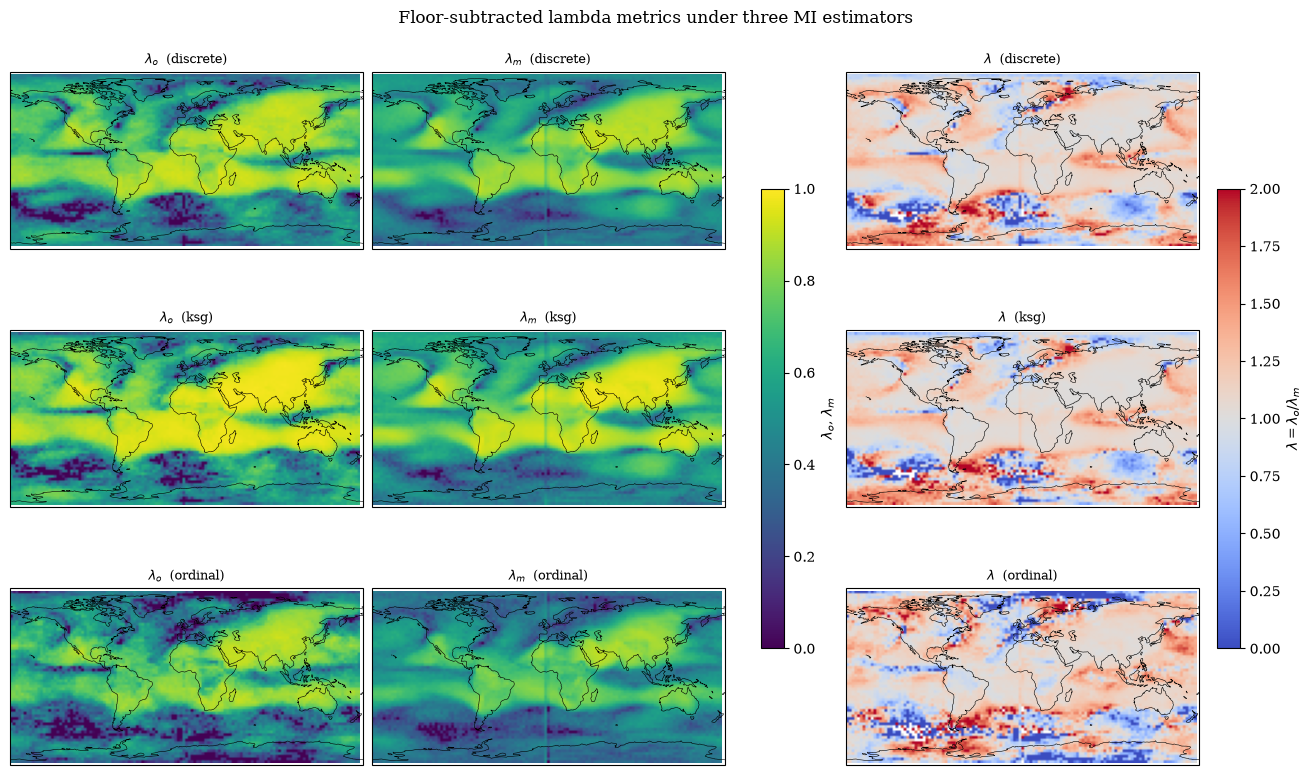

In [14]:
PROJ = ccrs.PlateCarree()

# The model grid runs 0..357.19 degrees east. Drawn with that extent in a global
# PlateCarree frame, cartopy wraps the eastern half round to the west and leaves a
# one-column white seam at the prime meridian -- data present, geography correct, but a
# visible stripe down every panel. Rolling the grid onto -180..180 first removes it.
LON180 = ((lons + 180) % 360) - 180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def _panel(ax, field, cmap, norm, title):
    ax.set_global()
    im_ = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                    cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4)
    ax.set_title(title, fontsize=9)
    return im_


n01 = Normalize(0, 1)
n02 = Normalize(0, 2)
fig, axs = plt.subplots(3, 3, figsize=(13, 8), layout="constrained",
                        subplot_kw={"projection": PROJ})
for i, name in enumerate(names):
    lo, lm, l = R.lambda_fields(res, name, floor=True)
    a = _panel(axs[i, 0], lo, "viridis", n01, r"$\lambda_o$  (%s)" % name)
    b = _panel(axs[i, 1], lm, "viridis", n01, r"$\lambda_m$  (%s)" % name)
    c = _panel(axs[i, 2], l, "coolwarm", n02, r"$\lambda$  (%s)" % name)
fig.colorbar(a, ax=axs[:, :2], shrink=0.6, label=r"$\lambda_o$, $\lambda_m$")
fig.colorbar(c, ax=axs[:, 2], shrink=0.6, label=r"$\lambda = \lambda_o/\lambda_m$")
fig.suptitle("Floor-subtracted lambda metrics under three MI estimators", fontsize=12)
plt.show()

### The nulls themselves, mapped

Worth looking at directly. A null field that has spatial structure is a warning: it means
the estimator's bias varies with the data, so subtracting a global constant would not
have worked.

That is exactly what separates the three. The binning and KSG nulls are spatially flat --
their bias is combinatorial, a function of $T$, `nbins` and $k$ but not of the data. The
**ordinal null is not flat**: it is visibly lower over the tropical oceans and higher
elsewhere, tracking the very structure the metric is supposed to measure. Its spatial
standard deviation is the largest of the three, on the largest mean. So for ordinal the
per-grid-point null is doing real work, and a single global correction would have left
the tropical/extratropical contrast partly intact as an artefact.

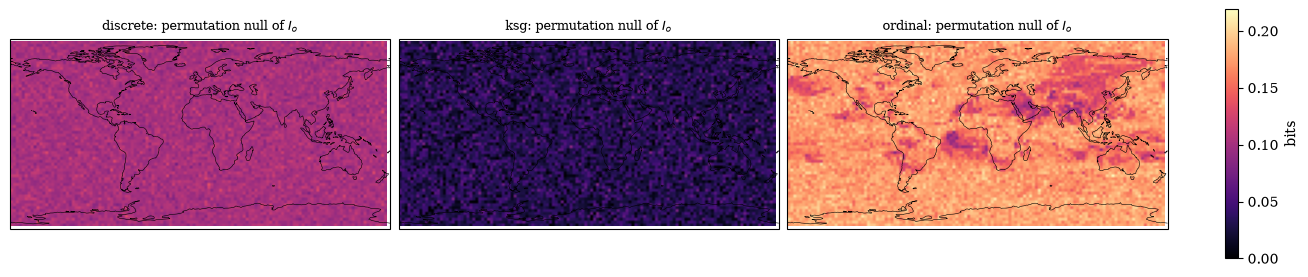

discrete  null_o  mean 0.1022  sd 0.0081  min 0.0735  max 0.1362
ksg       null_o  mean 0.0316  sd 0.0148  min -0.0243  max 0.0863
ordinal   null_o  mean 0.1677  sd 0.0188  min 0.0837  max 0.2192


In [15]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.2), layout="constrained",
                        subplot_kw={"projection": PROJ})
vmax = max(np.nanmax(res[n]["null_o"]) for n in names)
for ax, name in zip(axs, names):
    imh = _panel(ax, res[name]["null_o"], "magma", Normalize(0, vmax),
                 "%s: permutation null of $I_o$" % name)
fig.colorbar(imh, ax=axs, shrink=0.8, label="bits")
plt.show()

for name in names:
    n = res[name]["null_o"]
    print("%-9s null_o  mean %.4f  sd %.4f  min %.4f  max %.4f"
          % (name, np.nanmean(n), np.nanstd(n), np.nanmin(n), np.nanmax(n)))

## Parameter sensitivity

Each estimator's free parameter, swept over three values. A metric that moves a lot here
is not measuring the climate.

This is the single most decisive figure in the notebook. KSG's three histograms lie almost
exactly on top of one another -- $k$ barely matters. The binning histograms march steadily
rightward as `nbins` grows. And ordinal's are not even the same shape: `embedding_dim=4`
collapses into a narrow spike near $\lambda_o \approx 0.95$, which is saturation, not
skill -- 24 patterns over 117 windows leaves nothing to resolve, so almost every grid
point returns the same near-maximal value.

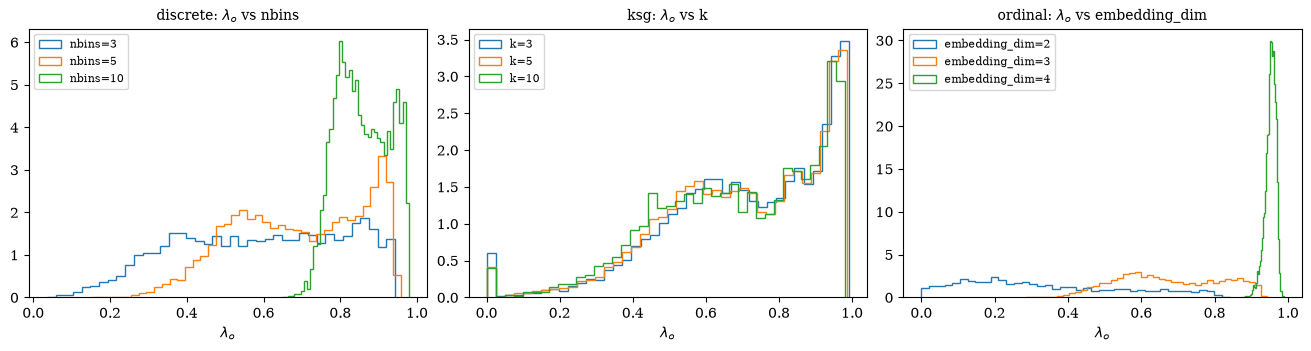

mean lambda_o per parameter value (raw, no null subtraction)
  discrete  nbins=3   0.591   nbins=5   0.690   nbins=10  0.856
  ksg       k=3   0.708   k=5   0.700   k=10  0.685
  ordinal   embedding_dim=2   0.335   embedding_dim=3   0.674   embedding_dim=4   0.952


In [16]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4), layout="constrained")
for ax, name in zip(axs, names):
    spec = res["params"][name]
    for j, v in enumerate(spec["values"]):
        lo = R.lam(res[name]["I_o"][j])
        ax.hist(lo[np.isfinite(lo)].ravel(), bins=40, histtype="step",
                density=True, label="%s=%s" % (spec["name"], v))
    ax.set_title("%s: $\\lambda_o$ vs %s" % (name, spec["name"]), fontsize=10)
    ax.set_xlabel(r"$\lambda_o$")
    ax.legend(fontsize=8)
plt.show()

print("mean lambda_o per parameter value (raw, no null subtraction)")
for name in names:
    spec = res["params"][name]
    print("  %-9s %s" % (name, "   ".join(
        "%s=%-3s %.3f" % (spec["name"], v, np.nanmean(R.lam(res[name]["I_o"][j])))
        for j, v in enumerate(spec["values"]))))

## What this does and does not settle

**What the comparison shows.** Read the floor-subtracted table and the spatial
correlations above; the numbers are printed rather than repeated here so they cannot
go stale.

**What `infomeasure` fixed.** The port is exact where it should be -- the adapter
reproduces the hand-rolled KSG number to $5\times10^{-7}$ bits -- and it removes three
hand-written estimators, gets a permutation test for free via `statistical_test()`, and
makes the binning / KSG / ordinal comparison a one-line change of `approach`.

**What it did not fix.** The dimensionality problem is a property of $N=49$ members
against $T=120$ timesteps, not of any implementation:

* The nulls are large. Even under the ensemble-mean reduction they are a substantial
  fraction of the signal for the discrete and ordinal estimators, which is why nothing
  here is reported without them.
* The 49-dimensional joint form remains available to KSG alone. Its own null was
  measured at $\approx 35\%$ of the signal in `calc_RPC_KSG.ipynb`, and reducing to the
  ensemble mean is what makes the three-way comparison possible at all -- it is a
  restriction, not an improvement.
* $\gamma$ is deliberately absent. Its denominator has broken three times, and the
  discrete joint-state estimator saturates completely at $N=49$: $5^{49}$ possible states
  for 120 samples means every timestep occupies its own state, so $\gamma \equiv 1$
  everywhere with a spatial standard deviation of $2.2\times10^{-3}$. Spatial structure in
  $\gamma$ survives only for $N \lesssim 4$. Adding more bins makes it worse, not better.
  $\lambda$ and $\rho$ need no normalisation and remain the metrics to trust.
* A longitude-wrap fix is still a prerequisite for any drop-based NaN policy. Columns 0
  and 127 are 20.7% and 42.9% NaN because the wrap-around is not handled before
  `interp_like`, so `nanfill="drop"` retains zero timesteps there. Everything above uses
  the published `nanfill="zero"`.